<h1>Tarea 4: árboles de decisión para regresión</h1>
<p>Jose Luis Romero Vazquez<p>
06/Agosto/2023

**1. Cargue los datos en Python usando Pandas y muestre los primeros 10 registros**

In [ ]:
# Tratamiento de datos
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt

# Preprocesado y modelado
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split # Import train_test_split function

# Configuración warnings
# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('once')

# para modelación
import sklearn
import imblearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error,accuracy_score,classification_report
from sklearn.metrics import confusion_matrix

from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV

# ==============================================================================
import pandas as pd
import numpy as np



# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns; sns.set()



# Preprocesado y modelado
# ==============================================================================
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataframe = pd.read_csv("CarPrice_Assignment.csv")
dataframe.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


**2. Muestre las dimensiones del dataframe (# renglones, #columnas)**

In [ ]:
dataframe.shape

(205, 26)

**3. Las columnas doornumber y cylindernumber tienen su valor con letra en inglés,
convierta estas columnas a numéricas.
replace(('zero','one','two','three','four','five','six','seven','eight','twelve'),
(0,1,2,3,4,5,6,7,8,12))**

In [ ]:
numbers=['zero','one','two','three','four','five','six','seven','eight']
i=0
while i<9:
 dataframe["doornumber"].replace(numbers[i],i,inplace=True)
 dataframe["cylindernumber"].replace(numbers[i],i,inplace=True)
 i=i+1
dataframe["cylindernumber"].replace("twelve",12,inplace=True)
dataframe[["doornumber","cylindernumber"]].head(5)

,doornumber,cylindernumber
0,2,4
1,2,4
2,2,6
3,4,4
4,4,5


**4. Muestre las estadísticas (media, desv est, cuartiles, max).**

In [ ]:
media = dataframe.mean()
p90 = dataframe.quantile([0.25, 0.5,0.75])
std1 = dataframe.std(ddof=0)
var1 = dataframe.var(ddof=0)
max1= dataframe.max
na=dataframe.isna()

print("media")
print(media)
print("cuartile")
print(p90)
print("desviacion estandar")
print(std1)
print("varianza")
print(var1)
print("Max")
print(max1)
print("Na")
print(na)

media
car_ID                103.000000
symboling               0.834146
doornumber              3.121951
wheelbase              98.756585
carlength             174.049268
carwidth               65.907805
carheight              53.724878
curbweight           2555.565854
cylindernumber          4.380488
enginesize            126.907317
boreratio               3.329756
stroke                  3.255415
compressionratio       10.142537
horsepower            104.117073
peakrpm              5125.121951
citympg                25.219512
highwaympg             30.751220
price               13276.710571
dtype: float64
cuartile
      car_ID  symboling  doornumber  wheelbase  carlength  carwidth  \
0.25    52.0        0.0         2.0       94.5      166.3      64.1   
0.50   103.0        1.0         4.0       97.0      173.2      65.5   
0.75   154.0        2.0         4.0      102.4      183.1      66.9   

      carheight  curbweight  cylindernumber  enginesize  boreratio  stroke  \
0.25       52

**5. Indique el número de valores faltantes por columna del dataframe.**

In [ ]:
dataframe.isna().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

**6. Muestre el tipo de todas las características (columnas) del dataframe.**

In [ ]:
dataframe.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber            int64
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber        int64
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

**7. Verifique que no hay renglones duplicados**

In [ ]:
dataframe.duplicated().sum()

0

**8. Realice el histograma y el diagrama de bigotes del precio.**

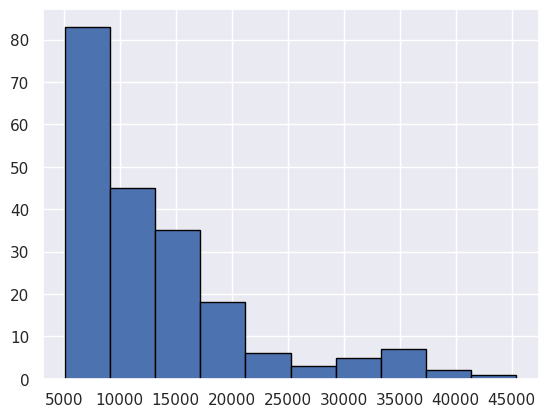

Primer cuartil:		 7788.0
Mediana:		 10295.0
Tercer cuartil:		 16503.0
Rango intercuartil:	 8715.0
Valor mínimo:		 5118.0
Valor máximo:		 45400.0
Bigote inferior:	 -5284.5
Bigote superior:	 29575.5


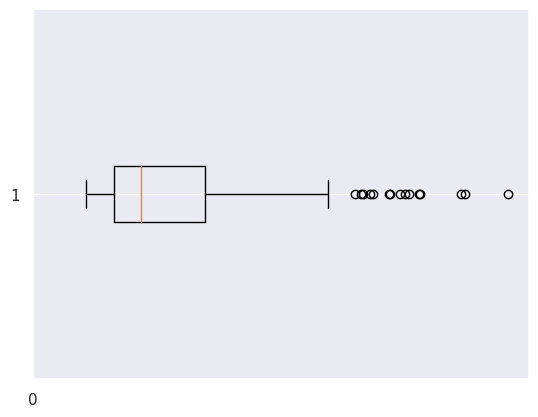

In [ ]:
plt.hist(dataframe["price"],edgecolor="black",linewidth=1)
plt.show()

Q1=dataframe["price"].quantile(0.25)
print("Primer cuartil:\t\t",Q1)
mediana=dataframe["price"].median()
print("Mediana:\t\t",mediana)
Q3=dataframe["price"].quantile(0.75)
print("Tercer cuartil:\t\t",Q3)
IQR=Q3-Q1
print("Rango intercuartil:\t",IQR)
minimo=dataframe["price"].min()
print("Valor mínimo:\t\t",minimo)
maximo=dataframe["price"].max()
print("Valor máximo:\t\t",maximo)

BI=Q1-1.5*IQR
BS=Q3+1.5*IQR
print("Bigote inferior:\t",BI)
print("Bigote superior:\t",BS)

plt.boxplot(dataframe["price"],vert=False)
plt.grid(True)
plt.xticks(np.arange(0,7,60))
plt.show()

**9. Como podrá observar la marca está incluida en el nombre del auto, extráigala con el
siguiente código**

In [ ]:
Company_Name = dataframe["CarName"].apply(lambda x: x.split(" ")[0])
dataframe.insert(2,"CompanyName",Company_Name)
# Now we can drop the CarName Feature.
dataframe.drop(columns=["CarName"],inplace=True)
dataframe.head()


,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi,gas,std,4,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi,gas,std,4,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


**10.Verifique los valores únicos de la marca**

In [ ]:
dataframe["CompanyName"].unique()

array(['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda',
       'isuzu', 'jaguar', 'maxda', 'mazda', 'buick', 'mercury',
       'mitsubishi', 'Nissan', 'nissan', 'peugeot', 'plymouth', 'porsche',
       'porcshce', 'renault', 'saab', 'subaru', 'toyota', 'toyouta',
       'vokswagen', 'volkswagen', 'vw', 'volvo'], dtype=object)

**11.Hay algunas marcas con errores por ejemplo maxda y mazda o vw y volkswagen.
Ejecute el siguiente remplazo para solucionarlo:**

In [ ]:
def replace (a, b):
 dataframe["CompanyName"].replace(a, b, inplace=True)
replace('maxda','mazda')
replace('porcshce','porsche')
replace('toyouta','toyota')
replace('vokswagen','volkswagen')
replace('vw','volkswagen')

**12.A partir de la marca y del precio promedio de cada marca agregue una columna que
indique la gama del automóvil (baja, media, alta) con el siguiente código:**

In [ ]:
z = round(dataframe.groupby(["CompanyName"])["price"].agg(["mean"]),2).T
z

CompanyName,Nissan,alfa-romero,audi,bmw,buick,chevrolet,dodge,honda,isuzu,jaguar,...,nissan,peugeot,plymouth,porsche,renault,saab,subaru,toyota,volkswagen,volvo
mean,5499.0,15498.33,17859.17,26118.75,33647.0,6007.0,7875.44,8184.69,8916.5,34600.0,...,10704.88,15489.09,7963.43,31400.5,9595.0,15223.33,8541.25,9885.81,10077.5,18063.18


**En la salida anterior, obtenemos el precio promedio de cada compañía de automóviles
individual
i) Primero se agrupa la información del dataframe por marca (CompanyName)
ii) Se trabaja con la columna Price
iii) agg es el equivalente en Python al aggregate de MongoDB.
A la salida anterior (Price agrupado por marca) le calcula el promedio (mean)
iv) El resultado se redondea a 2 decimales round(…,2)
v) Se obtiene la transpuesta .T para que el resultado quede como renglón
(opcional)
Ahora tenemos que agregar estos valores promedio en una nueva columna en
nuestro conjunto de datos.**

In [ ]:
dataframe = dataframe.merge(z.T,how="left",on="CompanyName")


**merge es el equivalente en Python al inner join de SQL, how=”left” indica que es left
join y on indica la columna por la que se relacionan**

In [ ]:
bins = [0,10000,20000,40000]
cars_bin=['Budget','Medium','Highend']
dataframe['CarsRange'] = pd.cut(dataframe['mean'], bins, right=False, labels=cars_bin)
dataframe.head()


,car_ID,symboling,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,mean,CarsRange
0,1,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,15498.33,Medium
1,2,3,alfa-romero,gas,std,2,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,15498.33,Medium
2,3,1,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,15498.33,Medium
3,4,2,audi,gas,std,4,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,17859.17,Medium
4,5,2,audi,gas,std,4,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,17859.17,Medium


**13.Elimine las columnas car_ID, enginelocation y symboling ya que una solo es un
identificador, la ubicación del motor no es importante y la otra no aporta información
valiosa al modelo.**

In [ ]:
dataframe.drop(['car_ID', 'enginelocation', 'symboling'], axis=1)

,CompanyName,fueltype,aspiration,doornumber,carbody,drivewheel,wheelbase,carlength,carwidth,carheight,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,mean,CarsRange
0,alfa-romero,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,13495.0,15498.33,Medium
1,alfa-romero,gas,std,2,convertible,rwd,88.6,168.8,64.1,48.8,...,3.47,2.68,9.0,111,5000,21,27,16500.0,15498.33,Medium
2,alfa-romero,gas,std,2,hatchback,rwd,94.5,171.2,65.5,52.4,...,2.68,3.47,9.0,154,5000,19,26,16500.0,15498.33,Medium
3,audi,gas,std,4,sedan,fwd,99.8,176.6,66.2,54.3,...,3.19,3.40,10.0,102,5500,24,30,13950.0,17859.17,Medium
4,audi,gas,std,4,sedan,4wd,99.4,176.6,66.4,54.3,...,3.19,3.40,8.0,115,5500,18,22,17450.0,17859.17,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,volvo,gas,std,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.78,3.15,9.5,114,5400,23,28,16845.0,18063.18,Medium
201,volvo,gas,turbo,4,sedan,rwd,109.1,188.8,68.8,55.5,...,3.78,3.15,8.7,160,5300,19,25,19045.0,18063.18,Medium
202,volvo,gas,std,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.58,2.87,8.8,134,5500,18,23,21485.0,18063.18,Medium
203,volvo,diesel,turbo,4,sedan,rwd,109.1,188.8,68.9,55.5,...,3.01,3.40,23.0,106,4800,26,27,22470.0,18063.18,Medium


**14.Realice los histogramas de las columnas categóricas vs Precio junto con los gráficos
de dispersión (scatterplot) de las columnas numéricas vs Precio.
plt.figure(figsize=(12, 30))
plt.subplot(8, 3, k + 1)**

10295.0


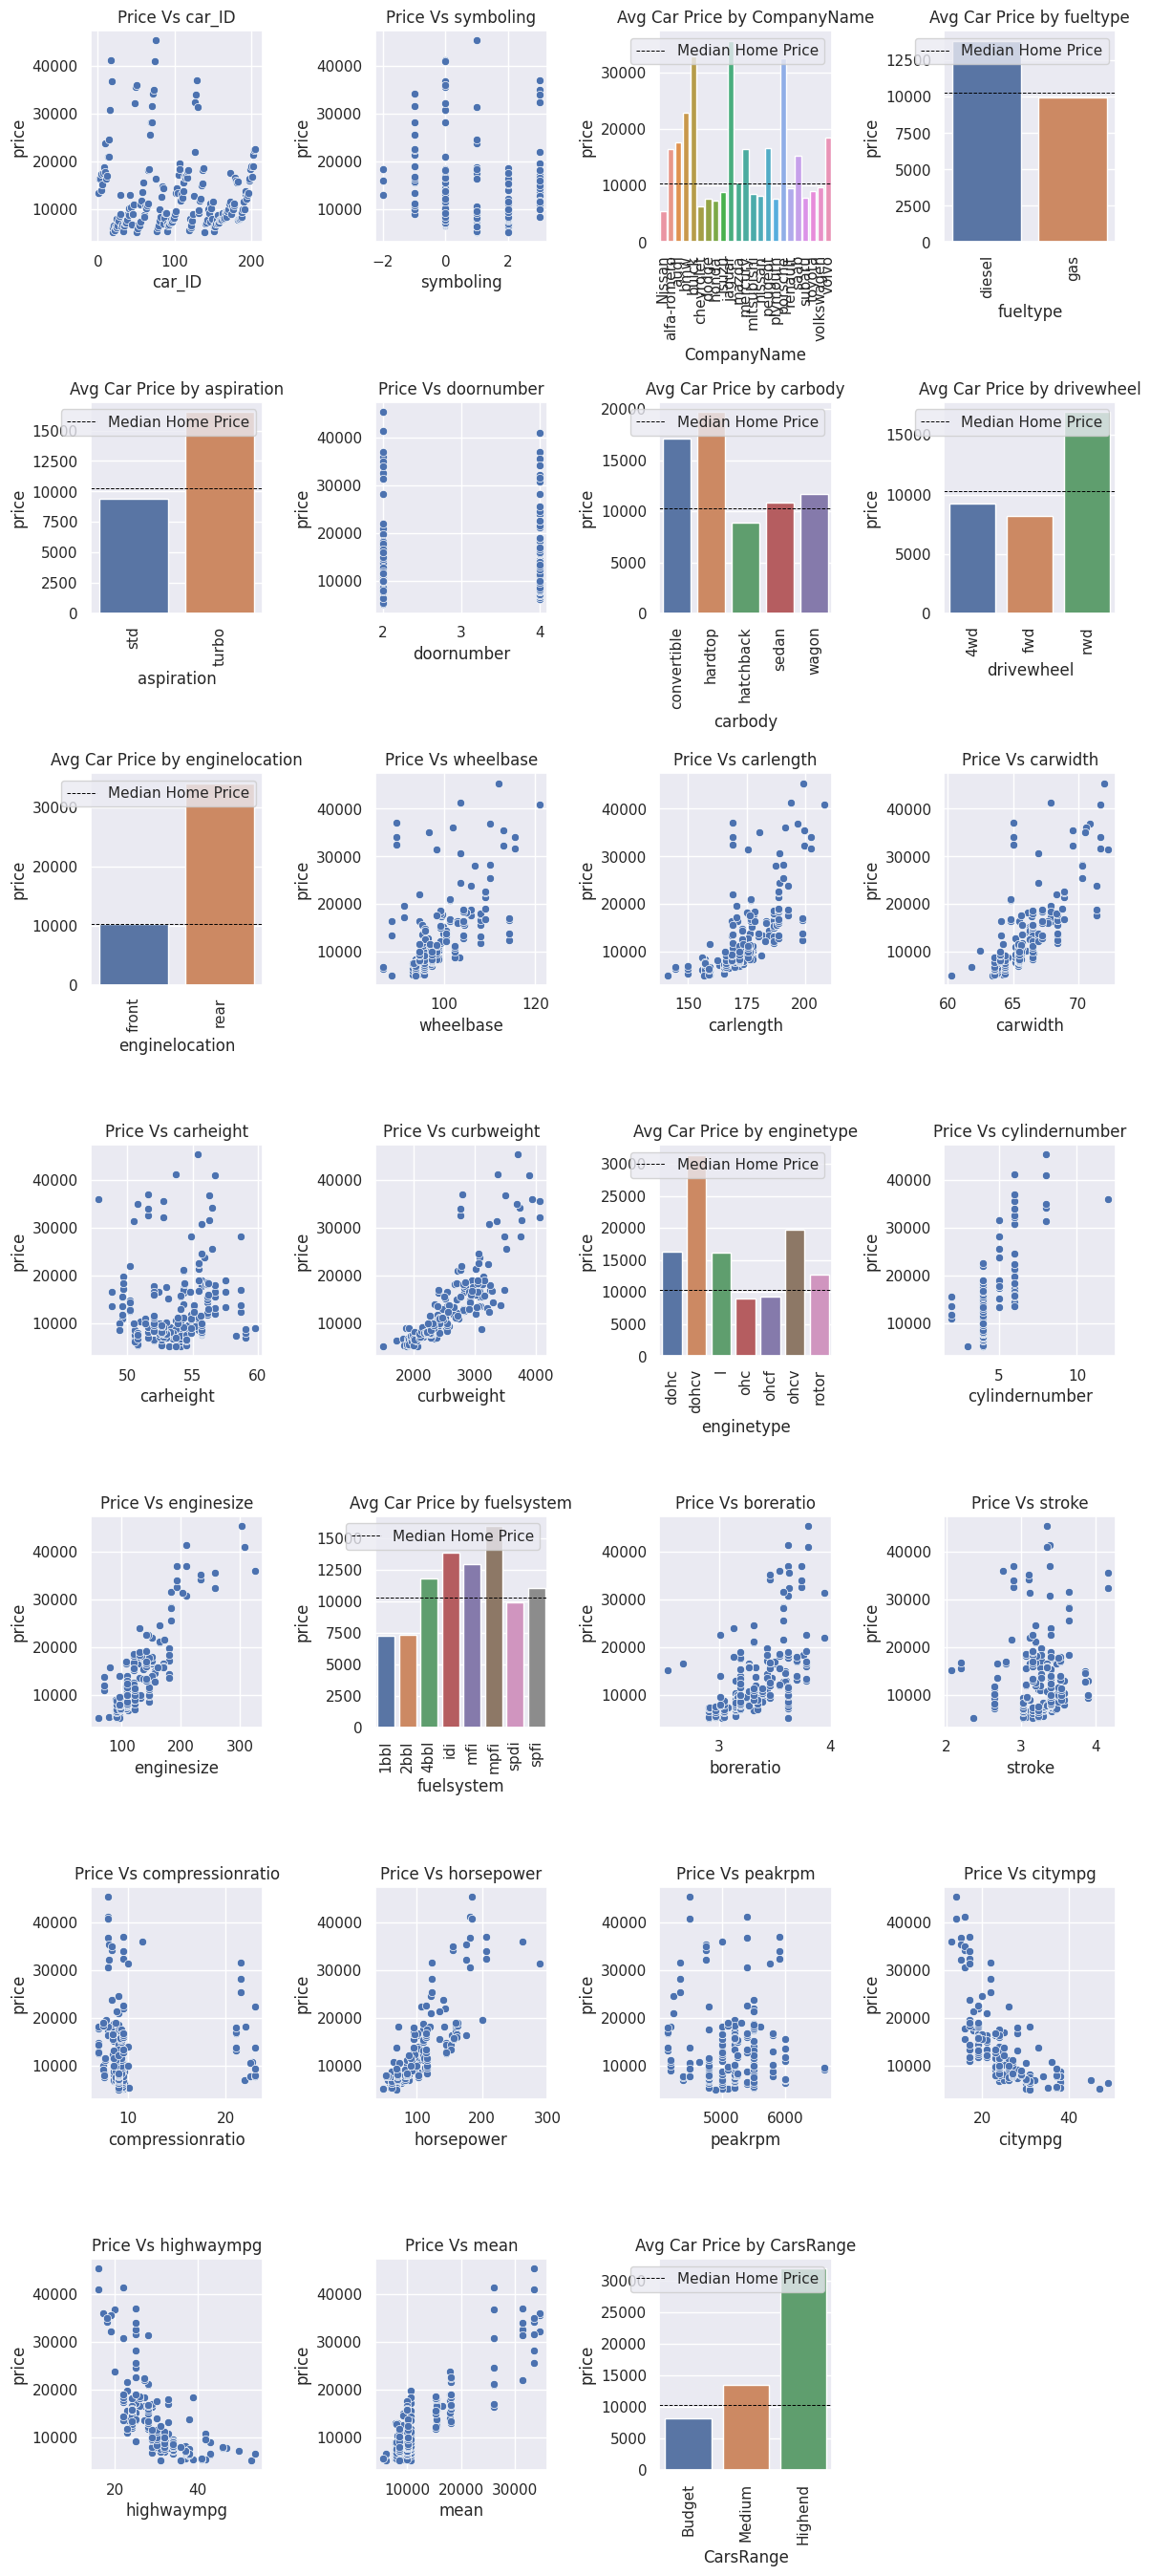

In [ ]:
viz_df = dataframe.copy()

median_home_price = viz_df['price'].median().round(2)

print(median_home_price)

k = 0

plt.figure(figsize=(12, 30))

for col in viz_df.drop('price', axis=1).columns:

    plt.subplot(8, 4, k + 1)

    if viz_df[col].dtype == 'float64' or viz_df[col].dtype =='int':

        sns.scatterplot(data=viz_df, x=col, y='price')

        plt.title(f"Price Vs {col}")

    else:

        group = viz_df[[col, 'price']].groupby(by=col).median()

        sns.barplot(data=group, x=group.index, y='price')

        plt.xticks(rotation=90)

        plt.axhline(y=median_home_price, label='Median Home Price', color='black', linestyle='--', linewidth=0.7)

        plt.title(f"Avg Car Price by {col}")

        plt.legend()

    k += 1

plt.tight_layout()

**15.Realice el diagrama de bigotes del precio respecto las siguientes características:**

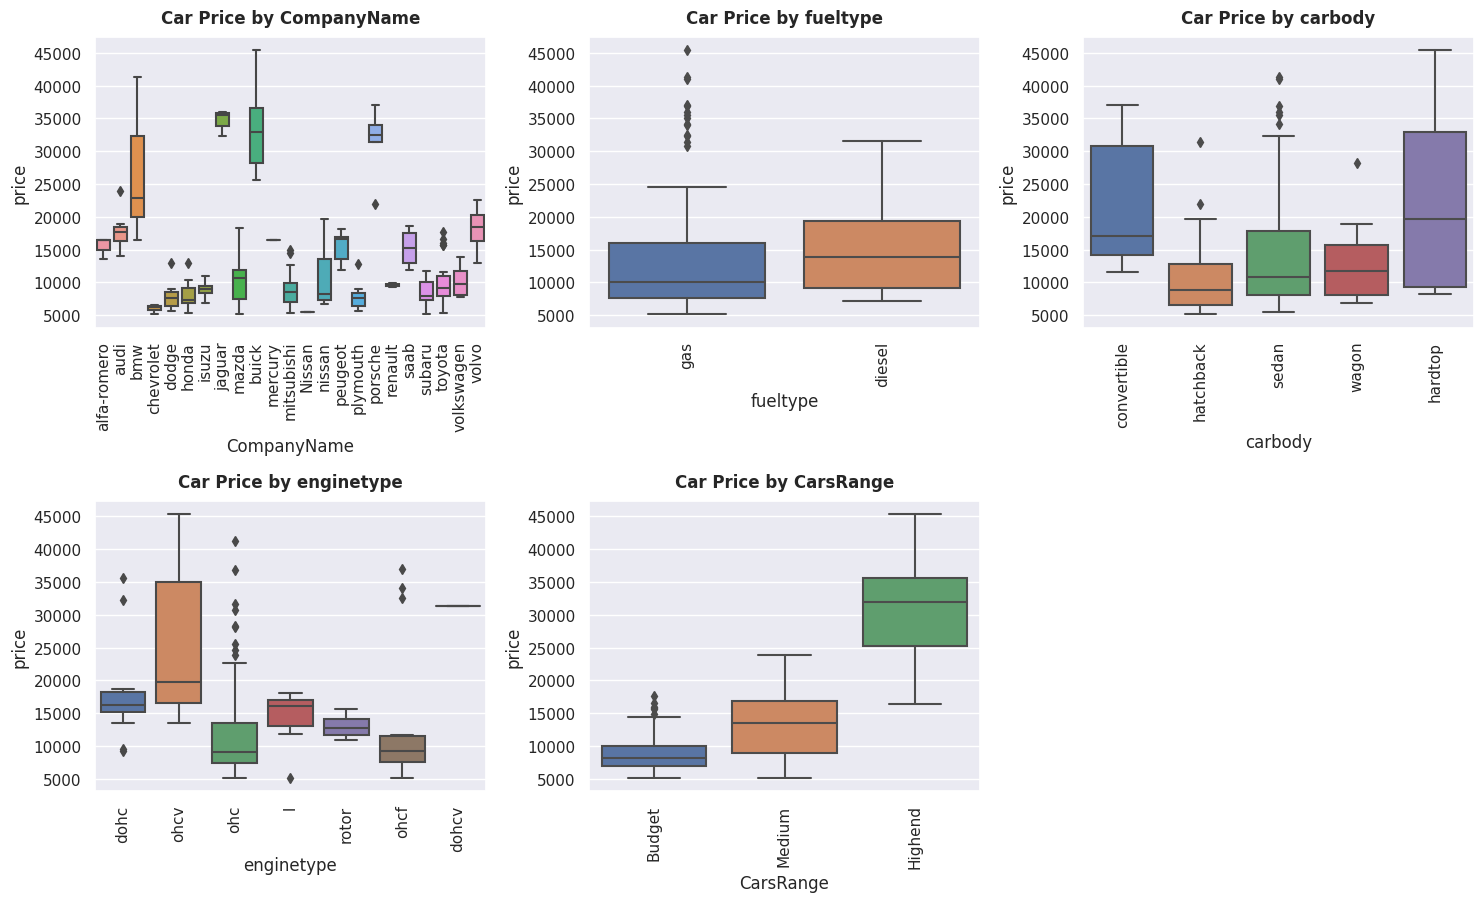

In [ ]:
k = 0
plt.figure(figsize=(15, 36))
columns=["CompanyName","fueltype","carbody","enginetype","CarsRange"]
for col in columns:
 plt.subplot(8, 3, k + 1)
 sns.boxplot(x=col,y="price",data=dataframe)
 plt.xticks(rotation=90)
 plt.title(f"Car Price by {col}", pad=10, fontweight="black", fontsize=12)
 k += 1
plt.tight_layout()

**16.Elimine las columnas con alta cardinalidad excepto enginetype pues esta
característica tiene un alto impacto en nuestra variable objetivo.**

In [ ]:
cat_cols = dataframe.select_dtypes('object').columns
k = 0
cardinality_cols = []



for col in cat_cols:
    value_counts = dataframe[col].value_counts(normalize=True).round(2)
    if len(value_counts) > 5 or len(value_counts) < 2:
        cardinality_cols.append(col)
    else:
        print("====================================================================")
        print(col)
        print(value_counts)



cardinality_cols.remove('enginetype')
print(f"Removed Columns: {cardinality_cols}")
dataframe.drop(columns=cardinality_cols, axis=1, inplace=True)

fueltype
gas       0.9
diesel    0.1
Name: fueltype, dtype: float64
aspiration
std      0.82
turbo    0.18
Name: aspiration, dtype: float64
carbody
sedan          0.47
hatchback      0.34
wagon          0.12
hardtop        0.04
convertible    0.03
Name: carbody, dtype: float64
drivewheel
fwd    0.59
rwd    0.37
4wd    0.04
Name: drivewheel, dtype: float64
enginelocation
front    0.99
rear     0.01
Name: enginelocation, dtype: float64
Removed Columns: ['CompanyName', 'fuelsystem']


**17.Elimine las columnas de varianza baja (ninguna, pero ejecute la prueba).**

In [ ]:
num_cols = dataframe.select_dtypes('number').columns

low_var_cols = []
for col in num_cols:
    scaled = (dataframe[col] - dataframe[col].mean()) / dataframe[col].std()
    variance = scaled.var().round(4)
    if variance == 0 or dataframe[col].std() == 0:
        low_var_cols.append(col)

dataframe.drop(columns=low_var_cols, axis=1, inplace=True)
print(f"Removed Columns: {low_var_cols}")
print(dataframe.shape, len(low_var_cols))

Removed Columns: []
(205, 26) 0


**18.Elimine las características que tienen una correlación mayor a 0.85**

In [ ]:
corr = dataframe.drop('price', axis=1).corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool_))
drop = [column for column in upper.columns if any(np.abs(upper[column]) > 0.85)]
print(f"columns dropped are: {drop}")
dataframe.drop(columns=drop, axis=1, inplace=True)

columns dropped are: ['carlength', 'curbweight', 'enginesize', 'highwaympg']


In [ ]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 205 entries, 0 to 204
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   car_ID            205 non-null    int64   
 1   symboling         205 non-null    int64   
 2   fueltype          205 non-null    object  
 3   aspiration        205 non-null    object  
 4   doornumber        205 non-null    int64   
 5   carbody           205 non-null    object  
 6   drivewheel        205 non-null    object  
 7   enginelocation    205 non-null    object  
 8   wheelbase         205 non-null    float64 
 9   carwidth          205 non-null    float64 
 10  carheight         205 non-null    float64 
 11  enginetype        205 non-null    object  
 12  cylindernumber    205 non-null    int64   
 13  boreratio         205 non-null    float64 
 14  stroke            205 non-null    float64 
 15  compressionratio  205 non-null    float64 
 16  horsepower        205 non-

**19.Para cada una de las columnas categóricas (object, categorical) ejecute el siguiente
código que calcula el precio promedio por categoría.
df[['fueltype','price']].groupby(['fueltype'], as_index = False).mean().sort_values(by =
'price', ascending = False)
• Para las columnas binarias remplace por 0 o 1 (fueltype, aspiration)
replace(("gas","diesel"),(0,1))
replace(("std","turbo"),(0,1))
• Para las columnas ordinales remplace por una escala numérica (CarsRange)
replace(("Budget","Medium","Highend"),(0,0.5,1))
• Para las columnas con menos de 9 categorias genere las columnas dummy en
formato one-hot (recuerde ordenar las columnas alfabeticamente) (carbody,
drivewheel, enginetype)
• Para el resto remplace por el valor promedio de cada categoría. (ninguna)**

In [ ]:
dataframe[['fueltype','price']].groupby(['fueltype'], as_index = False).mean().sort_values(by =
'price', ascending = False)

,fueltype,price
0,diesel,15838.1500
1,gas,12999.7982


In [ ]:
dataframe = pd.concat([
    dataframe.drop("fueltype", axis = 1),dataframe[["fueltype"]].replace(("gas","diesel"),(0,1))
], axis = 1)

In [ ]:
dataframe[['aspiration','price']].groupby(['aspiration'], as_index = False).mean().sort_values(by =
'price', ascending = False)

,aspiration,price
1,turbo,16298.166676
0,std,12611.270833


In [ ]:
dataframe = pd.concat([
    dataframe.drop("aspiration", axis = 1),
    dataframe[["aspiration"]].replace(("std","turbo"),(0,1))
], axis = 1)

In [ ]:
cat_columns = dataframe.select_dtypes(['category']).columns
dataframe[cat_columns] = dataframe[cat_columns].apply(lambda x: x.cat.codes)

In [ ]:
dataframe = pd.concat([
    dataframe.drop("CarsRange", axis = 1),dataframe[["CarsRange"]].replace(("Budget","Medium","Highend"),(0,0.5,1))
], axis = 1)

In [ ]:
data=pd.get_dummies(dataframe.carbody)
dataframe = pd.concat([dataframe.drop("carbody", axis = 1),data
], axis = 1)
data

,convertible,hardtop,hatchback,sedan,wagon
0,1,0,0,0,0
1,1,0,0,0,0
2,0,0,1,0,0
3,0,0,0,1,0
4,0,0,0,1,0
...,...,...,...,...,...
200,0,0,0,1,0
201,0,0,0,1,0
202,0,0,0,1,0
203,0,0,0,1,0


In [ ]:
data=pd.get_dummies(dataframe.drivewheel)
dataframe = pd.concat([
    dataframe.drop("drivewheel", axis = 1),data
], axis = 1)
data

,4wd,fwd,rwd
0,0,0,1
1,0,0,1
2,0,0,1
3,0,1,0
4,1,0,0
...,...,...,...
200,0,0,1
201,0,0,1
202,0,0,1
203,0,0,1


In [ ]:
dataframe = pd.concat([
    dataframe.drop("enginetype", axis = 1),pd.get_dummies(dataframe.enginetype)
], axis = 1)

In [ ]:
dataframe[['enginelocation','price']].groupby(['enginelocation'], as_index = False).mean().sort_values(by ='price', ascending = False)

,enginelocation,price
1,rear,34528.000000
0,front,12961.097361


In [ ]:
cat_columns = dataframe.select_dtypes(['object']).columns

print(cat_columns)

for c in cat_columns:

 dataframe[c]= dataframe[c].astype('category')

dataframe[cat_columns] = dataframe[cat_columns].apply(lambda x: x.cat.codes)

Index(['enginelocation'], dtype='object')


In [ ]:
dataframe.dtypes


car_ID                int64
symboling             int64
doornumber            int64
enginelocation         int8
wheelbase           float64
carwidth            float64
carheight           float64
cylindernumber        int64
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
price               float64
mean                float64
fueltype              int64
aspiration            int64
CarsRange              int8
convertible           uint8
hardtop               uint8
hatchback             uint8
sedan                 uint8
wagon                 uint8
4wd                   uint8
fwd                   uint8
rwd                   uint8
dohc                  uint8
dohcv                 uint8
l                     uint8
ohc                   uint8
ohcf                  uint8
ohcv                  uint8
rotor                 uint8
dtype: object

**20.Aplique las pruebas del factor de inflación de la varianza (VIF) para eliminar en cada
iteración la característica con el mayor coeficiente VIF hasta que todas queden con
un valor inferior a 5. Debe ignorar la columna objetivo price y las columnas
'horsepower' y 'carwidth' pues son de gran importancia para el modelo. También debe
ignorar todas las columnas dummy, pues marcarán infinito.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
ignorecolumns=['price', 'horsepower', 'carwidth', 'convertible', 'hardtop', 'hatchback',
'sedan', 'wagon', '4wd', 'fwd', 'rwd', 'dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
X=dataframe.drop(ignorecolumns,axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.2,car_ID
1,3.1,symboling
2,22.7,doornumber
3,1.7,enginelocation
4,1143.9,wheelbase
5,943.7,carheight
6,35.9,cylindernumber
7,273.5,boreratio
8,131.4,stroke
9,563.5,compressionratio


In [ ]:
del dataframe['symboling']
ignorecolumns=['price', 'horsepower', 'carwidth', 'convertible', 'hardtop', 'hatchback',
'sedan', 'wagon', '4wd', 'fwd', 'rwd', 'dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
X=dataframe.drop(ignorecolumns,axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.1,car_ID
1,16.1,doornumber
2,1.6,enginelocation
3,1119.7,wheelbase
4,943.1,carheight
5,35.7,cylindernumber
6,266.4,boreratio
7,127.2,stroke
8,540.9,compressionratio
9,200.7,peakrpm


In [ ]:
del dataframe['enginelocation']
ignorecolumns=['price', 'horsepower', 'carwidth', 'convertible', 'hardtop', 'hatchback',
'sedan', 'wagon', '4wd', 'fwd', 'rwd', 'dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
X=dataframe.drop(ignorecolumns,axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,6.0,car_ID
1,16.1,doornumber
2,898.0,wheelbase
3,906.8,carheight
4,35.5,cylindernumber
5,251.6,boreratio
6,127.2,stroke
7,540.3,compressionratio
8,186.1,peakrpm
9,52.2,citympg


In [ ]:
del dataframe['aspiration']
ignorecolumns=['price', 'horsepower', 'carwidth', 'convertible', 'hardtop', 'hatchback',
'sedan', 'wagon', '4wd', 'fwd', 'rwd', 'dohc', 'dohcv', 'l', 'ohc', 'ohcf', 'ohcv', 'rotor']
X=dataframe.drop(ignorecolumns,axis=1)
vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif.round(1)

,VIF Factor,features
0,5.9,car_ID
1,15.8,doornumber
2,896.0,wheelbase
3,902.1,carheight
4,35.5,cylindernumber
5,246.2,boreratio
6,127.2,stroke
7,406.6,compressionratio
8,169.0,peakrpm
9,52.2,citympg


**21.Muestre los primeros 10 renglones del dataframe actual y sus dimensiones.**

In [ ]:
print(X.shape)
X.head(10)

(205, 13)


,car_ID,doornumber,wheelbase,carheight,cylindernumber,boreratio,stroke,compressionratio,peakrpm,citympg,mean,fueltype,CarsRange
0,1,2,88.6,48.8,4,3.47,2.68,9.0,5000,21,15498.33,0,1
1,2,2,88.6,48.8,4,3.47,2.68,9.0,5000,21,15498.33,0,1
2,3,2,94.5,52.4,6,2.68,3.47,9.0,5000,19,15498.33,0,1
3,4,4,99.8,54.3,4,3.19,3.40,10.0,5500,24,17859.17,0,1
4,5,4,99.4,54.3,5,3.19,3.40,8.0,5500,18,17859.17,0,1
5,6,2,99.8,53.1,5,3.19,3.40,8.5,5500,19,17859.17,0,1
6,7,4,105.8,55.7,5,3.19,3.40,8.5,5500,19,17859.17,0,1
7,8,4,105.8,55.7,5,3.19,3.40,8.5,5500,19,17859.17,0,1
8,9,4,105.8,55.9,5,3.13,3.40,8.3,5500,17,17859.17,0,1
9,10,2,99.5,52.0,5,3.13,3.40,7.0,5500,16,17859.17,0,1


**23.Separe los datos en 80% entrenamiento y 20% pruebas (Xtrain, Xtest, Ytrain, Ytest)**

In [ ]:
X = dataframe.drop('price',axis=1)
Y = dataframe['price']
Xtrain, Xtest, Ytrain, Ytest = train_test_split(X,Y.values.reshape(-1,1),test_size=0.20, random_state=42)

**24.Genere un primer árbol de regresión con los siguientes parámetros y entrénelo:
modelo = DecisionTreeRegressor(random_state = 123)**

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


ERROR: Could not find a version that satisfies the requirement RandomForestRegressor (from versions: none)
ERROR: No matching distribution found for RandomForestRegressor


In [ ]:
# Preprocesado y modelado
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split # Import train_test_split function


# ------------------------------------------------------------------------------
import warnings
warnings.filterwarnings('once')


import sklearn
import imblearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import r2_score , mean_absolute_error, mean_squared_error,accuracy_score,classification_report
from sklearn.metrics import confusion_matrix


from sklearn.tree import plot_tree
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
from sklearn.model_selection import GridSearchCV

In [ ]:
modelo = DecisionTreeRegressor( random_state = 123)

**25.Haga las predicciones con los datos de prueba.**

In [ ]:
modelo = modelo.fit(Xtrain,Ytrain)

In [ ]:
y_pred = modelo.predict(Xtest)

In [ ]:
y_pred

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


array([37028. , 16503. ,  8949. , 12170. , 31600. ,  6669. ,  5399. ,
        8058. , 11694. ,  7975. , 13845. ,  8358. , 16558. , 11248. ,
       45400. ,  6338. ,  5572. , 14869. ,  6989. , 11694. , 10245. ,
       13950. ,  7499. ,  5389. ,  7609. , 37028. ,  8449. , 16515. ,
        7499. , 15985. , 31600. ,  6669. ,  8778. , 18920. ,  7957. ,
       31600. , 11694. , 11845. ,  8916.5, 14869. ,  8845. ])

**26.Calcule el el R2 score y los errores (MAE, MSE, RMSE) de las predicciones.**

In [ ]:

score = r2_score(Ytest, y_pred)
mae = mean_absolute_error(Ytest, y_pred)
mse = mean_squared_error(Ytest, y_pred)
rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print("Rendimiento en pruebas:")
print("-------------------------------")
print('r2_score is', score)
print('MAE is ', mae)
print('MSE is ', mse)
print('RMSE is ',rmse)

Rendimiento en pruebas:
-------------------------------
r2_score is 0.9377349477651039
MAE is  1608.5406585365854
MSE is  4915453.583704609
RMSE is  2217.0822230365316


**27.Realice el grafico 2d para comparar el valor real contra las predicciones del modelo.**

In [ ]:
# Error de test del modelo inicial
#-------------------------------------------------------------------------------
predicciones = modelo.predict(X = Xtest)
rmse = mean_squared_error(
        y_true  = Ytest,
        y_pred  = predicciones,
        squared = False
       )
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 2217.0822230365316


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/numpy/core/shape_base.py:65: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  ary = asanyarray(ary)


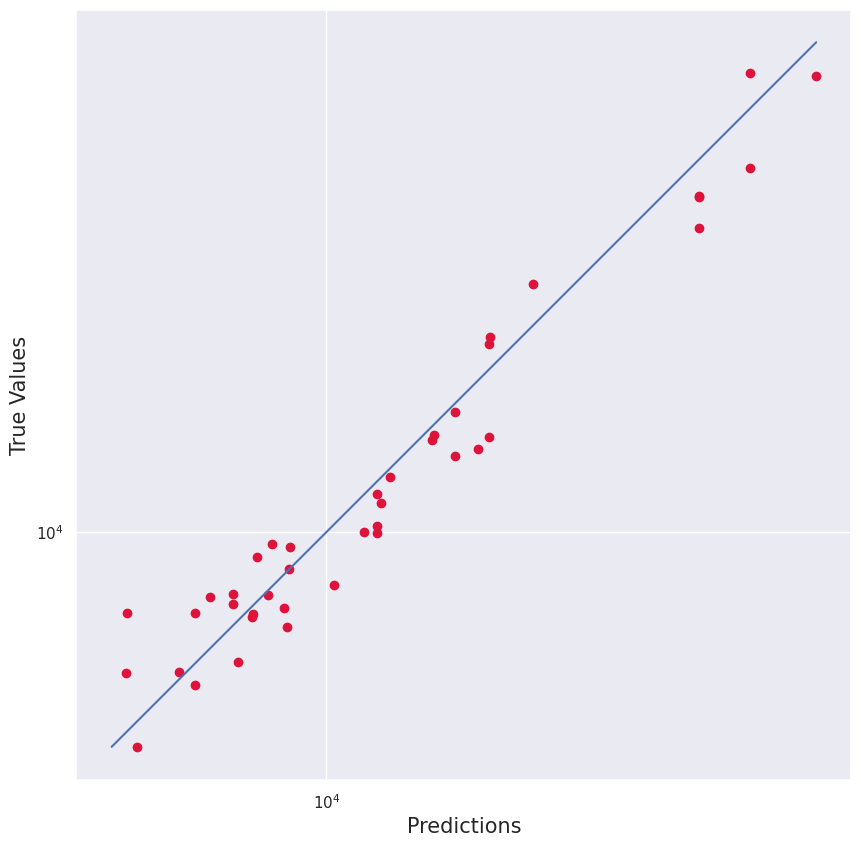

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(y_pred, Ytest, c='crimson')
plt.yscale('log')
plt.xscale('log')



p1 = max(max(y_pred), max(Ytest))
p2 = min(min(y_pred), min(Ytest))
plt.plot([p1, p2], [p1, p2], 'b-')
plt.xlabel('Predictions', fontsize=15)
plt.ylabel('True Values', fontsize=15)
plt.axis('equal')
plt.show()

**28.Realice el diagrama del árbol con los siguientes parámetros y con ayuda de GIMP o
Photoshop exporte el árbol a JPG
figsize=(120, 25)
feature_names = Xtest.columns**

Profundidad del árbol: 14
Número de nodos terminales: 159


<frozen importlib._bootstrap>:914: ImportWarning: APICoreClientInfoImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _OpenCVImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:914: ImportWarning: _AltairImportHook.find_spec() not found; falling back to find_module()


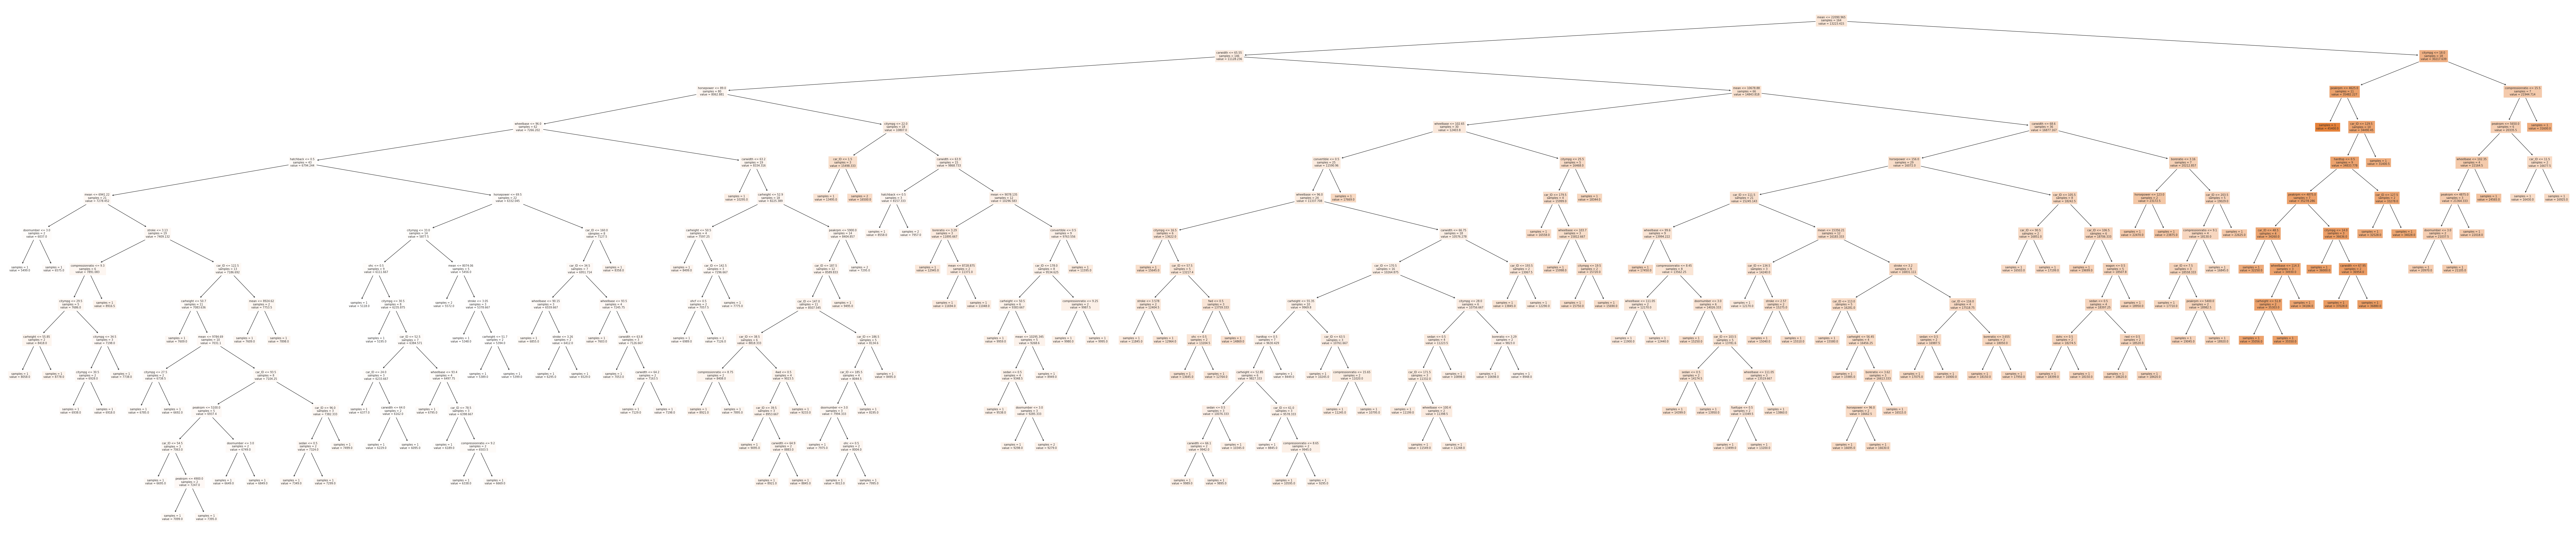

In [ ]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(120, 25))

print(f"Profundidad del árbol: {modelo.get_depth()}")
print(f"Número de nodos terminales: {modelo.get_n_leaves()}")

plot = plot_tree(
            decision_tree = modelo,
            feature_names = Xtest.columns,

            filled        = True,
            impurity      = False,
            fontsize      = 7,
            ax            = ax
       )
plt.savefig('tree.eps',format='eps',bbox_inches = "tight")

**29.Muestre la información del 1er registro de prueba y haga un recorrido desde la raíz
hasta la hoja que le corresponde para verificar que el precio coincide con
predicciones[0]
pd.set_option('display.max_columns', None)
Xtest.head(1)**

In [ ]:
predicciones[0]
pd.set_option('display.max_columns', None)
Xtest.head(1)

,car_ID,doornumber,wheelbase,carwidth,carheight,cylindernumber,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,mean,fueltype,CarsRange,convertible,hardtop,hatchback,sedan,wagon,4wd,fwd,rwd,dohc,dohcv,l,ohc,ohcf,ohcv,rotor
15,16,4,103.5,66.9,55.7,6,3.62,3.39,8.0,182,5400,16,26118.75,0,2,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0


**30.Realice una búsqueda por validación cruzada con el objeto GridSearchCV para
analizar si usando una poda del árbol el modelo mejora. Use los siguientes
parámetros:**

/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/tree/_classes.py:277: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0'`.
  warnings.warn(
/usr/local/lib/python3.10/di

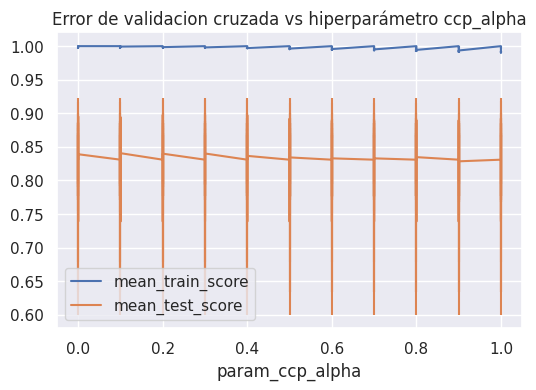

In [ ]:
param_grid = {'criterion':["squared_error", "friedman_mse", "absolute_error", "poisson"],
 'max_features': [None,'log2', 'sqrt','auto'],
'ccp_alpha': [0,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
}

# Búsqueda por validación cruzada
grid = GridSearchCV(
        # El árbol se crece al máximo posible antes de aplicar el pruning
        estimator = DecisionTreeRegressor(
                            random_state      = 123
                       ),
        param_grid = param_grid,

        refit      = True,
        return_train_score = True
      )
grid.fit(Xtrain, Ytrain)

fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");

**31.Revise cual fue la mejor configuración encontrada (grid.best_params_) y muestre su
profundidad y número de hojas para comprobar que el árbol que generó al inicio es el
mejor posible para este ejercicio**

In [ ]:
grid.best_params_

{'ccp_alpha': 0.2, 'criterion': 'poisson', 'max_features': 'sqrt'}

/usr/local/lib/python3.10/dist-packages/pandas/plotting/_matplotlib/core.py:792: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  handles = leg.legendHandles


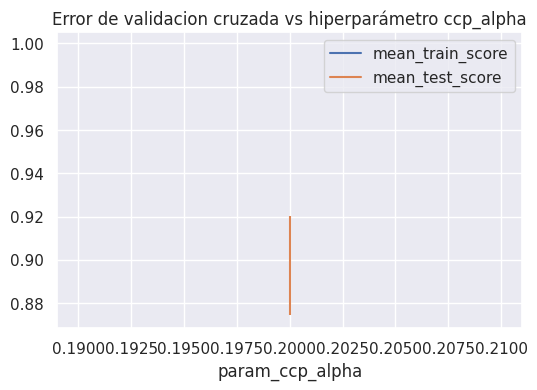

In [ ]:
param_grid = {'criterion':["poisson"],
 'max_features': ['sqrt'],
'ccp_alpha': [0.2],
}

# Búsqueda por validación cruzada
grid = GridSearchCV(
        # El árbol se crece al máximo posible antes de aplicar el pruning
        estimator = DecisionTreeRegressor(
                            random_state      = 123
                       ),
        param_grid = param_grid,

        refit      = True,
        return_train_score = True
      )
grid.fit(Xtrain, Ytrain)

fig, ax = plt.subplots(figsize=(6, 3.84))
scores = pd.DataFrame(grid.cv_results_)
scores.plot(x='param_ccp_alpha', y='mean_train_score', yerr='std_train_score', ax=ax)
scores.plot(x='param_ccp_alpha', y='mean_test_score', yerr='std_test_score', ax=ax)
ax.set_title("Error de validacion cruzada vs hiperparámetro ccp_alpha");